# Student Performance Prediction System

## Project Objective

The objective of this project is to build a machine learning model that predicts a student's final academic marks based on academic and personal factors.

### Input Features

- Study Hours
- Attendance
- Previous Score
- Assignment Score
- Gender
- Parent Education

### Target Variable

- Final Marks

### Machine Learning Models

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

In [2]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.2.2
NumPy version: 1.26.4


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
df = pd.read_csv(
    "../data/student_performance_dataset.csv"
)

In [7]:
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [9]:
df.shape

(708, 10)

In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 708
Number of columns: 10


In [11]:
df.columns.tolist()

['Student_ID',
 'Gender',
 'Study_Hours_per_Week',
 'Attendance_Rate',
 'Past_Exam_Scores',
 'Parental_Education_Level',
 'Internet_Access_at_Home',
 'Extracurricular_Activities',
 'Final_Exam_Score',
 'Pass_Fail']

In [12]:
df.dtypes

Student_ID                     object
Gender                         object
Study_Hours_per_Week            int64
Attendance_Rate               float64
Past_Exam_Scores                int64
Parental_Education_Level       object
Internet_Access_at_Home        object
Extracurricular_Activities     object
Final_Exam_Score                int64
Pass_Fail                      object
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [14]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [15]:
df.describe(include="object")

,Student_ID,Gender,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Pass_Fail
count,708,708,708,708,708,708
unique,500,2,4,2,2,2
top,S339,Female,Bachelors,No,No,Pass
freq,6,375,189,381,361,354


In [16]:
df.isnull().sum()

Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

In [17]:
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


In [18]:
df.duplicated().sum()

208

In [19]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print("Duplicate rows:", duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%"
)

Duplicate rows: 208
Duplicate percentage: 29.38%


In [20]:
duplicate_rows = df[
    df.duplicated(keep=False)
]
duplicate_rows.head(10)

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass
5,S417,Male,30,84.159193,77,Masters,Yes,No,61,Pass
6,S302,Male,24,89.389494,95,High School,Yes,Yes,61,Pass
8,S044,Female,34,80.863186,94,PhD,No,Yes,65,Pass
16,S327,Male,32,93.031601,78,Bachelors,Yes,Yes,77,Pass
20,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
22,S375,Male,36,97.220486,93,Masters,Yes,Yes,65,Pass
24,S207,Female,20,89.075724,92,Bachelors,Yes,Yes,62,Pass


In [21]:
duplicate_rows.shape

(320, 10)

In [22]:
df_cleaned = df.drop_duplicates().copy()

In [23]:
df_cleaned.shape

(500, 10)

In [24]:
df_cleaned.duplicated().sum()

0

In [25]:
categorical_columns = [
    "Gender",
    "Parental_Education_Level",
    "Internet_Access_at_Home",
    "Extracurricular_Activities",
    "Pass_Fail"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df_cleaned[column].value_counts())


Gender
Gender
Female    256
Male      244
Name: count, dtype: int64

Parental_Education_Level
Parental_Education_Level
High School    135
Bachelors      127
PhD            121
Masters        117
Name: count, dtype: int64

Internet_Access_at_Home
Internet_Access_at_Home
No     263
Yes    237
Name: count, dtype: int64

Extracurricular_Activities
Extracurricular_Activities
No     268
Yes    232
Name: count, dtype: int64

Pass_Fail
Pass_Fail
Fail    354
Pass    146
Name: count, dtype: int64


In [26]:
df_cleaned.to_csv(
    "../data/student_performance_cleaned.csv",
    index=False
)

In [27]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Data Cleaning Summary

The dataset initially contained 708 rows and 10 columns.

### Missing Values

No missing values were found in the dataset. Therefore, no imputation was required during the initial cleaning process.

### Duplicate Records

A total of 208 duplicate rows were identified.

These exact duplicate records were removed to prevent repeated observations from influencing exploratory analysis and machine learning model training.

After duplicate removal:

- Original rows: 708
- Duplicate rows removed: 208
- Final unique rows: 500

### Identifier Column

The `Student_ID` column is an identifier and will not be used as a predictive feature because it does not represent meaningful academic or personal information.

### Target Leakage Prevention

The `Pass_Fail` column will not be used as an input feature when predicting `Final_Exam_Score`, because it may be directly derived from final exam performance and could introduce target leakage.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of student performance, identify relationships between academic factors and final exam scores, and detect patterns that may influence model predictions.

The analysis focuses on:

- Distribution of final exam scores
- Study hours and academic performance
- Attendance and academic performance
- Past exam scores and final performance
- Gender-based performance differences
- Parental education and performance
- Internet access and performance
- Extracurricular activities and performance
- Correlation among numerical variables

In [28]:
df_cleaned.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,500.000000,500.000000,500.000000,500.000000
mean,25.184000,75.830689,75.218000,56.378000
std,8.804384,13.969186,14.442841,6.266551
min,10.000000,50.116970,50.000000,50.000000
25%,18.000000,64.959340,62.000000,50.000000
50%,26.000000,76.752661,75.500000,55.000000
75%,33.000000,87.548861,88.000000,61.000000
max,39.000000,99.967675,100.000000,77.000000


In [29]:
df_cleaned["Final_Exam_Score"].describe()

count    500.000000
mean      56.378000
std        6.266551
min       50.000000
25%       50.000000
50%       55.000000
75%       61.000000
max       77.000000
Name: Final_Exam_Score, dtype: float64

In [30]:
print(
    "Average Final Exam Score:",
    round(df_cleaned["Final_Exam_Score"].mean(), 2)
)

print(
    "Median Final Exam Score:",
    df_cleaned["Final_Exam_Score"].median()
)

print(
    "Minimum Final Exam Score:",
    df_cleaned["Final_Exam_Score"].min()
)

print(
    "Maximum Final Exam Score:",
    df_cleaned["Final_Exam_Score"].max()
)

Average Final Exam Score: 56.38
Median Final Exam Score: 55.0
Minimum Final Exam Score: 50
Maximum Final Exam Score: 77


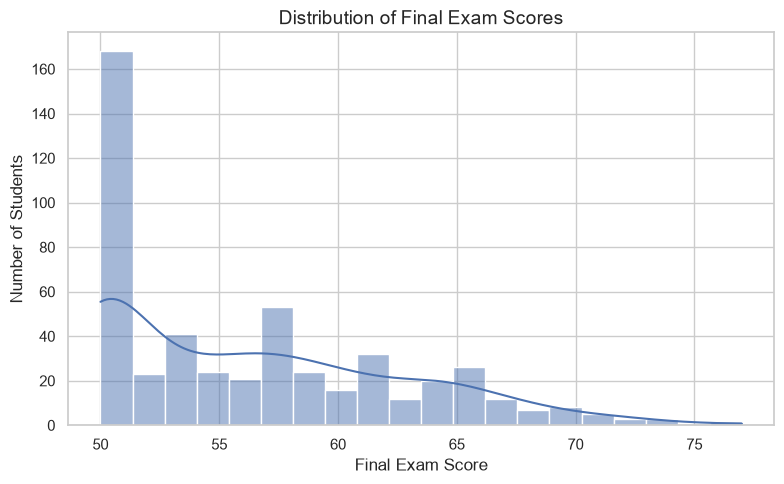

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_cleaned,
    x="Final_Exam_Score",
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Final Exam Scores",
    fontsize=14
)

plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Observation

The distribution plot shows how final exam scores are spread across students. Most observations are concentrated within the central score ranges, while fewer students appear near the extreme values.

This analysis helps identify the overall pattern and variability of the target variable before model training.

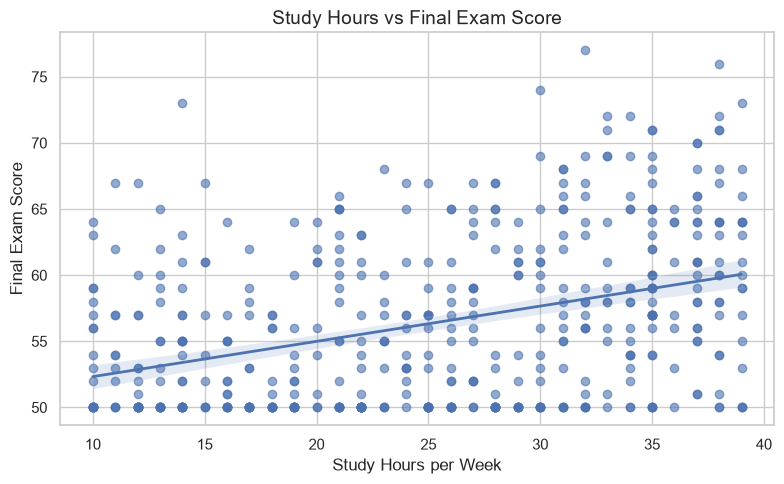

In [33]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_cleaned,
    x="Study_Hours_per_Week",
    y="Final_Exam_Score",
    scatter_kws={
        "alpha": 0.6
    },
    line_kws={
        "linewidth": 2
    }
)

plt.title(
    "Study Hours vs Final Exam Score",
    fontsize=14
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [34]:
study_correlation = df_cleaned[
    "Study_Hours_per_Week"
].corr(
    df_cleaned["Final_Exam_Score"]
)

print(
    "Correlation between Study Hours and Final Exam Score:",
    round(study_correlation, 3)
)

Correlation between Study Hours and Final Exam Score: 0.375


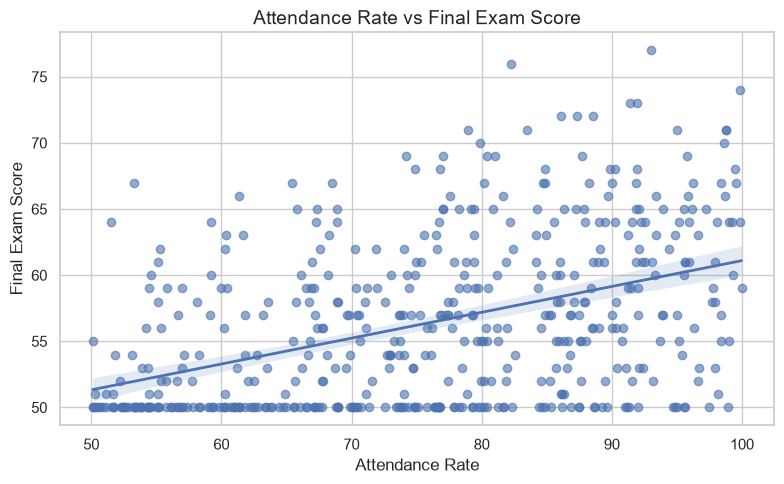

In [35]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_cleaned,
    x="Attendance_Rate",
    y="Final_Exam_Score",
    scatter_kws={
        "alpha": 0.6
    },
    line_kws={
        "linewidth": 2
    }
)

plt.title(
    "Attendance Rate vs Final Exam Score",
    fontsize=14
)

plt.xlabel("Attendance Rate")
plt.ylabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [36]:
attendance_correlation = df_cleaned[
    "Attendance_Rate"
].corr(
    df_cleaned["Final_Exam_Score"]
)

print(
    "Correlation between Attendance and Final Exam Score:",
    round(attendance_correlation, 3)
)

Correlation between Attendance and Final Exam Score: 0.436


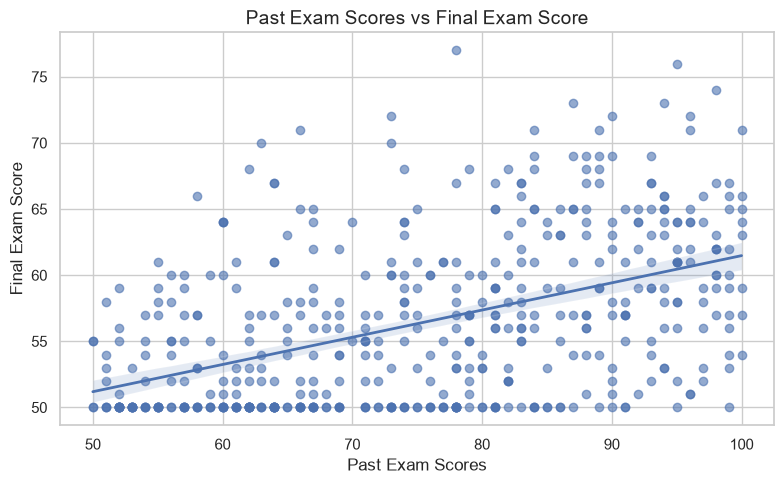

In [37]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_cleaned,
    x="Past_Exam_Scores",
    y="Final_Exam_Score",
    scatter_kws={
        "alpha": 0.6
    },
    line_kws={
        "linewidth": 2
    }
)

plt.title(
    "Past Exam Scores vs Final Exam Score",
    fontsize=14
)

plt.xlabel("Past Exam Scores")
plt.ylabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [38]:
past_score_correlation = df_cleaned[
    "Past_Exam_Scores"
].corr(
    df_cleaned["Final_Exam_Score"]
)

print(
    "Correlation between Past Exam Scores and Final Exam Score:",
    round(past_score_correlation, 3)
)

Correlation between Past Exam Scores and Final Exam Score: 0.474


### Observation

This visualization examines whether previous academic performance is associated with final exam performance.

The regression line indicates the overall direction of the relationship, while the correlation coefficient quantifies its linear strength.

In [39]:
relationship_summary = pd.Series({
    "Study Hours": study_correlation,
    "Attendance Rate": attendance_correlation,
    "Past Exam Scores": past_score_correlation
})

relationship_summary = (
    relationship_summary
    .sort_values(ascending=False)
)

relationship_summary

Past Exam Scores    0.474257
Attendance Rate     0.435714
Study Hours         0.374708
dtype: float64

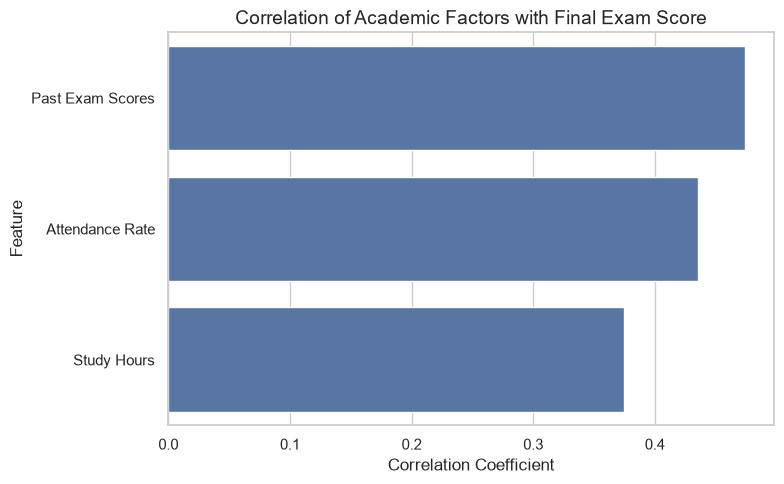

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=relationship_summary.values,
    y=relationship_summary.index
)

plt.title(
    "Correlation of Academic Factors with Final Exam Score",
    fontsize=14
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [41]:
df_cleaned["Gender"].value_counts()

Gender
Female    256
Male      244
Name: count, dtype: int64

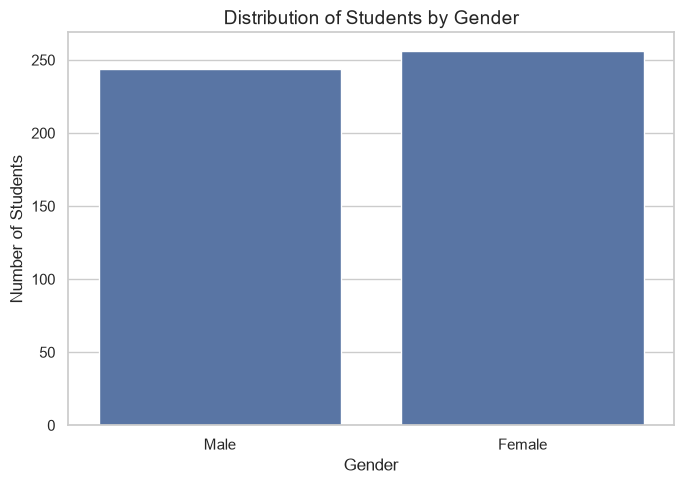

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_cleaned,
    x="Gender"
)

plt.title(
    "Distribution of Students by Gender",
    fontsize=14
)

plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

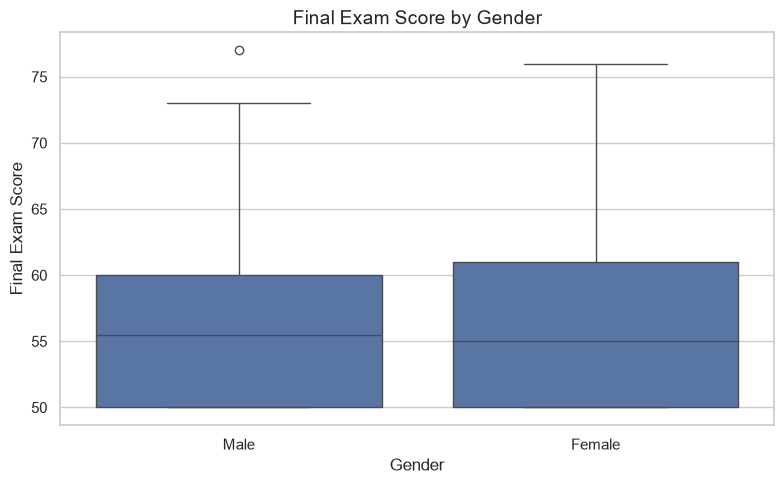

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_cleaned,
    x="Gender",
    y="Final_Exam_Score"
)

plt.title(
    "Final Exam Score by Gender",
    fontsize=14
)

plt.xlabel("Gender")
plt.ylabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [44]:
gender_performance = (
    df_cleaned
    .groupby("Gender")["Final_Exam_Score"]
    .agg(["mean", "median", "count"])
    .round(2)
)

gender_performance

,mean,median,count
Gender,,,
Female,56.49,55.0,256
Male,56.26,55.5,244


In [45]:
df_cleaned[
    "Parental_Education_Level"
].value_counts()

Parental_Education_Level
High School    135
Bachelors      127
PhD            121
Masters        117
Name: count, dtype: int64

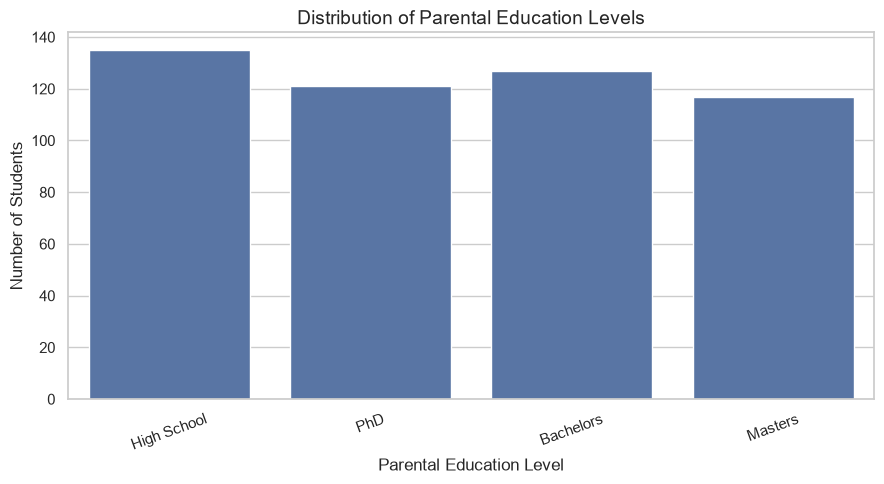

In [46]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_cleaned,
    x="Parental_Education_Level"
)

plt.title(
    "Distribution of Parental Education Levels",
    fontsize=14
)

plt.xlabel("Parental Education Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

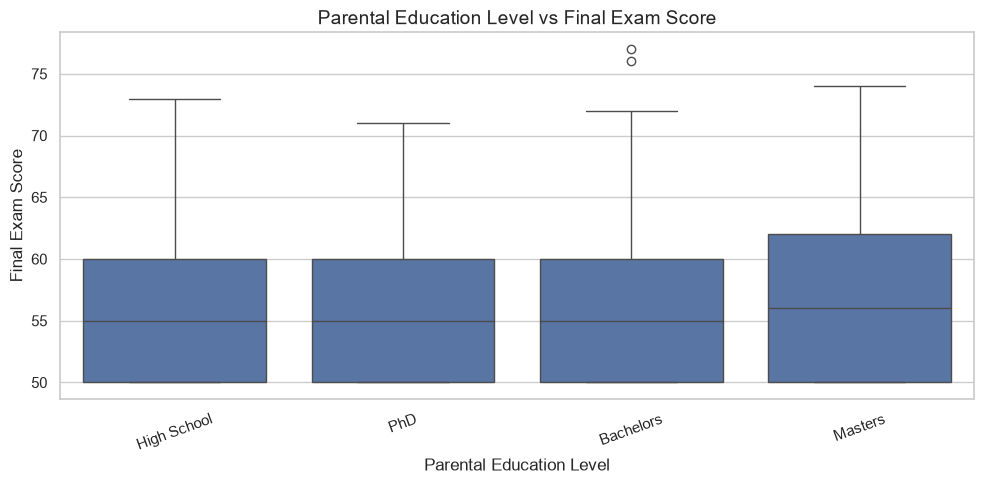

In [47]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_cleaned,
    x="Parental_Education_Level",
    y="Final_Exam_Score"
)

plt.title(
    "Parental Education Level vs Final Exam Score",
    fontsize=14
)

plt.xlabel("Parental Education Level")
plt.ylabel("Final Exam Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [48]:
parent_education_performance = (
    df_cleaned
    .groupby(
        "Parental_Education_Level"
    )["Final_Exam_Score"]
    .agg(["mean", "median", "count"])
    .round(2)
)

parent_education_performance

,mean,median,count
Parental_Education_Level,,,
Bachelors,56.22,55.0,127
High School,56.23,55.0,135
Masters,57.00,56.0,117
PhD,56.11,55.0,121


In [49]:
df_cleaned[
    "Internet_Access_at_Home"
].value_counts()

Internet_Access_at_Home
No     263
Yes    237
Name: count, dtype: int64

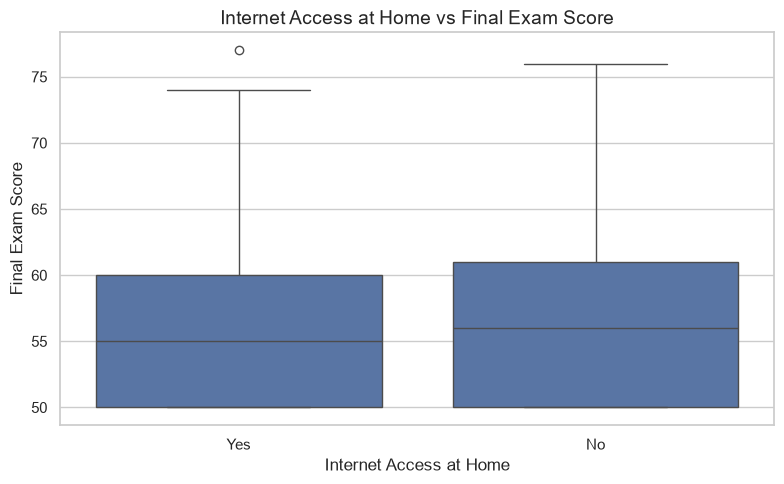

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_cleaned,
    x="Internet_Access_at_Home",
    y="Final_Exam_Score"
)

plt.title(
    "Internet Access at Home vs Final Exam Score",
    fontsize=14
)

plt.xlabel("Internet Access at Home")
plt.ylabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [51]:
internet_performance = (
    df_cleaned
    .groupby(
        "Internet_Access_at_Home"
    )["Final_Exam_Score"]
    .agg(["mean", "median", "count"])
    .round(2)
)

internet_performance

,mean,median,count
Internet_Access_at_Home,,,
No,56.51,56.0,263
Yes,56.24,55.0,237


In [52]:
df_cleaned[
    "Extracurricular_Activities"
].value_counts()

Extracurricular_Activities
No     268
Yes    232
Name: count, dtype: int64

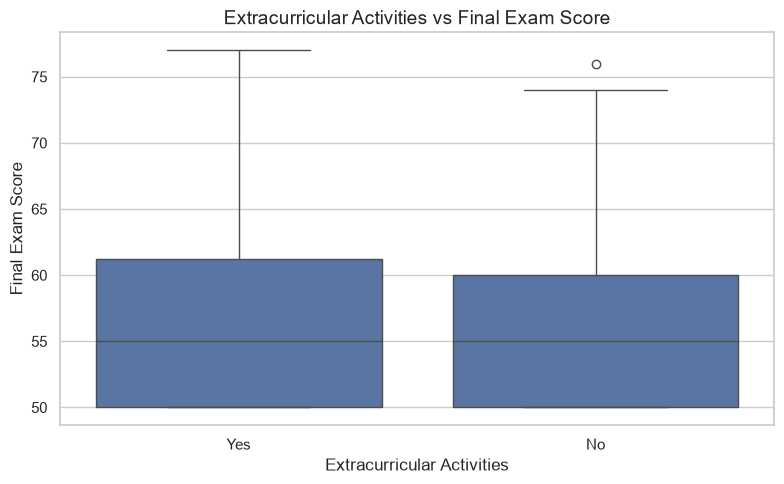

In [53]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_cleaned,
    x="Extracurricular_Activities",
    y="Final_Exam_Score"
)

plt.title(
    "Extracurricular Activities vs Final Exam Score",
    fontsize=14
)

plt.xlabel("Extracurricular Activities")
plt.ylabel("Final Exam Score")

plt.tight_layout()
plt.show()

In [54]:
activity_performance = (
    df_cleaned
    .groupby(
        "Extracurricular_Activities"
    )["Final_Exam_Score"]
    .agg(["mean", "median", "count"])
    .round(2)
)

activity_performance

,mean,median,count
Extracurricular_Activities,,,
No,56.12,55.0,268
Yes,56.68,55.0,232


In [55]:
numerical_columns = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Past_Exam_Scores",
    "Final_Exam_Score"
]

correlation_matrix = df_cleaned[
    numerical_columns
].corr()

correlation_matrix

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
Study_Hours_per_Week,1.000000,-0.039701,-0.013381,0.374708
Attendance_Rate,-0.039701,1.000000,-0.022741,0.435714
Past_Exam_Scores,-0.013381,-0.022741,1.000000,0.474257
Final_Exam_Score,0.374708,0.435714,0.474257,1.000000


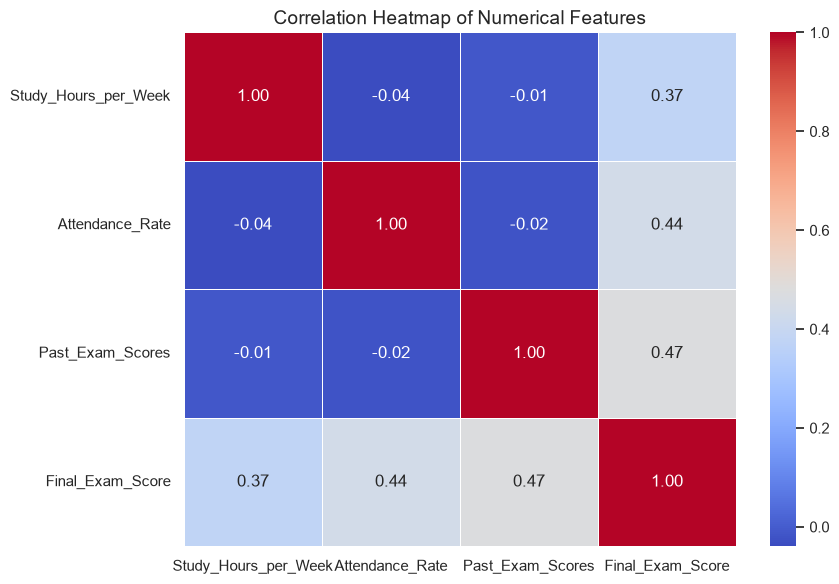

In [56]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [57]:
df_cleaned["Pass_Fail"].value_counts()

Pass_Fail
Fail    354
Pass    146
Name: count, dtype: int64

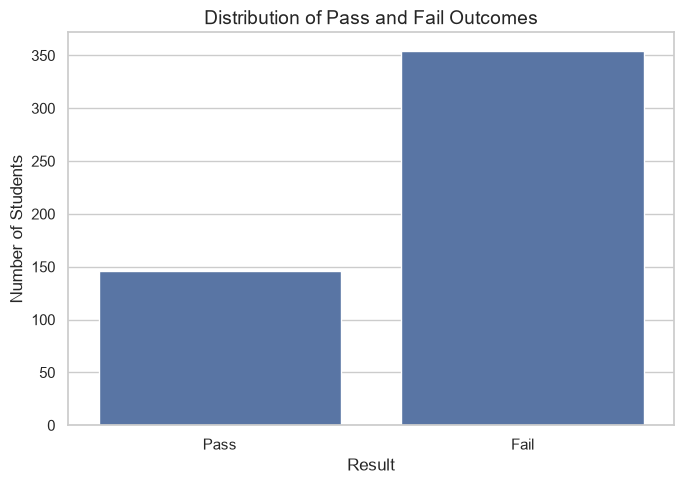

In [58]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_cleaned,
    x="Pass_Fail"
)

plt.title(
    "Distribution of Pass and Fail Outcomes",
    fontsize=14
)

plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [59]:
target_correlations = (
    correlation_matrix["Final_Exam_Score"]
    .drop("Final_Exam_Score")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlations

Past_Exam_Scores        0.474257
Attendance_Rate         0.435714
Study_Hours_per_Week    0.374708
Name: Final_Exam_Score, dtype: float64

## EDA Summary

The exploratory data analysis examined the distribution of final exam scores and the relationships between student performance and academic or personal factors.

Key areas analyzed included:

- Weekly study hours and final exam performance
- Attendance rate and final exam performance
- Past exam scores and final exam performance
- Performance differences across categorical groups
- Correlations among numerical variables
- Distribution of pass/fail outcomes

The analysis provides an empirical basis for feature preparation and machine learning model development.

The next stage will prepare the feature matrix and target variable, remove non-predictive identifiers, prevent target leakage, encode categorical variables, split the dataset into training and testing sets, and construct preprocessing pipelines.

## Data Preprocessing and Feature Preparation

In this stage, the cleaned dataset is prepared for machine learning.

The preprocessing workflow includes:

- Defining input features and target variable
- Removing non-predictive identifier columns
- Preventing target leakage
- Splitting data into training and testing sets
- Identifying numerical and categorical features
- Scaling numerical features
- Encoding categorical features
- Building a reusable preprocessing pipeline

The target variable for this regression problem is `Final_Exam_Score`.

In [60]:
X = df_cleaned.drop(
    columns=[
        "Student_ID",
        "Final_Exam_Score",
        "Pass_Fail"
    ]
)

In [61]:
y = df_cleaned["Final_Exam_Score"]

In [62]:
X.head()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities
0,Male,31,68.267841,86,High School,Yes,Yes
1,Male,16,78.222927,73,PhD,No,No
2,Female,21,87.525096,74,PhD,Yes,No
3,Female,27,92.076483,99,Bachelors,No,No
4,Female,37,98.655517,63,Masters,No,Yes


In [63]:
X.columns.tolist()

['Gender',
 'Study_Hours_per_Week',
 'Attendance_Rate',
 'Past_Exam_Scores',
 'Parental_Education_Level',
 'Internet_Access_at_Home',
 'Extracurricular_Activities']

In [64]:
y.head()

0    63
1    50
2    55
3    65
4    70
Name: Final_Exam_Score, dtype: int64

In [65]:
y.shape

(500,)

In [66]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (500, 7)
Target vector shape: (500,)


In [67]:
print("Features used for prediction:")

for column in X.columns:
    print("-", column)

Features used for prediction:
- Gender
- Study_Hours_per_Week
- Attendance_Rate
- Past_Exam_Scores
- Parental_Education_Level
- Internet_Access_at_Home
- Extracurricular_Activities


In [68]:
assert "Student_ID" not in X.columns
assert "Final_Exam_Score" not in X.columns
assert "Pass_Fail" not in X.columns

print(
    "Identifier and leakage columns removed successfully!"
)

Identifier and leakage columns removed successfully!


In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 7)
X_test shape: (100, 7)
y_train shape: (400,)
y_test shape: (100,)


In [72]:
numerical_features = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Past_Exam_Scores"
]

In [73]:
X_train[numerical_features].head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores
294,33,95.775684,89
582,12,93.175907,66
19,39,85.197307,62
402,25,95.028615,65
417,28,58.336538,51


In [74]:
categorical_features = [
    "Gender",
    "Parental_Education_Level",
    "Internet_Access_at_Home",
    "Extracurricular_Activities"
]

In [75]:
X_train[categorical_features].head()

,Gender,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities
294,Male,Masters,Yes,No
582,Male,PhD,No,No
19,Female,PhD,Yes,No
402,Male,Masters,Yes,Yes
417,Female,Bachelors,No,No


In [76]:
print(
    "Number of numerical features:",
    len(numerical_features)
)

print(
    "Number of categorical features:",
    len(categorical_features)
)

print(
    "Total selected features:",
    len(numerical_features)
    + len(categorical_features)
)

Number of numerical features: 3
Number of categorical features: 4
Total selected features: 7


In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [78]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [79]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [81]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours_per_Week', 'Attendance_Rate',
                                  'Past_Exam_Scores']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Parental_Education_Level',
                                  'Internet_Access_at_Home',
                                  'Extracurricular_Activities'])])

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [85]:
model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours_per_Week',
                                                   'Attendance_Rate',
                                                   'Past_Exam_Scores']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Parental_Education_Level',
                                                   'Internet_Access_at_Home',
                                                   'Extracurricular_Activities'])])),
                ('model', LinearRegression())])

In [86]:
model_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours_per_Week',
                                                   'Attendance_Rate',
                                                   'Past_Exam_Scores']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Parental_Education_Level',
                                                   'Internet_Access_at_Home',
                                                   'Extracurricular_Activities'])])),
                ('model', LinearRegression())])

In [87]:
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [88]:
y_pred_linear = model_pipeline.predict(
    X_test
)

In [89]:
y_pred_linear[:10]

array([52.74557799, 59.10827681, 51.06417516, 54.79560394, 55.49282197,
       47.83571106, 55.5453813 , 63.45061766, 49.07268958, 57.57979744])

In [90]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred_linear
})

comparison.head(10)

,Actual Score,Predicted Score
0,51,52.745578
1,63,59.108277
2,50,51.064175
3,55,54.795604
4,66,55.492822
5,50,47.835711
6,50,55.545381
7,68,63.450618
8,50,49.072690
9,59,57.579797


In [91]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "Numerical features:",
    numerical_features
)

print(
    "Categorical features:",
    categorical_features
)

print(
    "Target variable:",
    y.name
)

Training samples: 400
Testing samples: 100
Numerical features: ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores']
Categorical features: ['Gender', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities']
Target variable: Final_Exam_Score
